# Class-Based Quantum Digital Signature Protocol with Noisy Quantum Public-Key Transmission

This notebook implements a Gottesman-Chuang style Quantum Digital Signature (QDS) workflow with a single class. Quantum noise is modeled only as a transmission effect on distributed public-key states.

## Imports

The implementation uses Qiskit circuits, Qiskit Aer simulation, Aer quantum error channels, NumPy randomness, and Matplotlib visualization.

In [1]:
import warnings
from typing import Any, Dict, List, Optional, Sequence, Tuple

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    amplitude_damping_error,
    depolarizing_error,
    pauli_error,
    phase_damping_error,
)

print("Imports completed.")

Imports completed.


## Short Mathematical Background

For each message bit position, Alice prepares two families of private classical keys, one family for signing a `0` and one family for signing a `1`. For copy index `i`, the private keys are

$$
k_0^{(b,i)}, k_1^{(b,i)} \in \{0,1\}^{L}.
$$

The public key is obtained from a quantum one-way map. In the one-qubit case, if `j = int(k, 2)` and

$$
\theta = \frac{\pi}{2^L},
$$

then the public state is

$$
|f_k\rangle = \cos(j\theta)|0\rangle + \sin(j\theta)|1\rangle
              = R_Y(2j\theta)|0\rangle.
$$

For an `n`-qubit public key, the `L`-bit private key is split into `n` consecutive chunks. If chunk `q` has length `L_q`, integer value `j_q`, and angle spacing `theta_q = pi / 2^{L_q}`, then

$$
|f_k\rangle = \bigotimes_{q=0}^{n-1}
\left(\cos(j_q\theta_q)|0\rangle_q + \sin(j_q\theta_q)|1\rangle_q\right).
$$

The security-margin diagnostic used here is

$$
\text{security\_margin} = L - nM.
$$

A positive value indicates that the private-key length exceeds the Holevo-accessible public information scale `nM`. Non-positive values are allowed for experimentation, but they are weak choices.

### Public-Key Transmission Noise

The physical sequence implemented in this notebook is:

1. Alice samples classical private keys.
2. Alice prepares ideal public-key states `|f_k>`.
3. The quantum public keys pass through a selected noisy channel.
4. The verifier stores the received noisy public keys.
5. Alice signs by revealing classical private keys only.
6. The verifier rebuilds the ideal inverse preparation circuit from each revealed key.
7. The verifier applies that ideal inverse circuit to the received public key and measures all qubits.

Thus, noise is applied after public-key preparation and before verification. It is not applied to private-key generation, ideal state preparation, classical signatures, inverse verification gates, or simulator operations globally.

### Global Acceptance Rule

For a message of length `N` and `M` public-key copies per bit, the verifier performs

$$
T = N M
$$

checks. Each check passes if the measured probability of the all-zero state after inverse verification is at least `verification_pass_threshold`. Let `s` be the total number of failed checks. The global thresholds are

$$
\tau_1 = c_1 T, \qquad \tau_2 = c_2 T, \qquad 0 < c_1 < c_2 < 1.
$$

The verdict is

$$
\begin{cases}
\texttt{ACCEPT\_AUTHENTIC}, & s \leq \tau_1,\\
\texttt{REJECT\_FORGED}, & s \geq \tau_2,\\
\texttt{INCONCLUSIVE}, & \tau_1 < s < \tau_2.
\end{cases}
$$

## Full Class Implementation

The complete protocol is implemented inside one class. Public-key state preparation is ideal. Channel noise is appended only during public-key transmission.

In [2]:
class QuantumDigitalSignatureWithChannelNoise:
    """Class-based Gottesman-Chuang style QDS protocol.

    The class stores ideal public-key circuits and received public-key circuits
    separately. Noise is inserted only by appending a quantum channel to each
    public-key qubit after ideal public-key preparation.
    """

    ALLOWED_NOISE_CHANNELS = {
        "none",
        "depolarizing",
        "amplitude_damping",
        "phase_damping",
        "bit_flip",
        "phase_flip",
    }

    ACCEPT_AUTHENTIC = "ACCEPT_AUTHENTIC"
    REJECT_FORGED = "REJECT_FORGED"
    INCONCLUSIVE = "INCONCLUSIVE"

    def __init__(
        self,
        message_bits: str,
        n_qubits: int = 4,
        L: int = 25,
        M: int = 5,
        c1: float = 0.1,
        c2: float = 0.4,
        shots: int = 4096,
        seed: int = 42,
        noise_channel: str = "none",
        noise_probability: float = 0.0,
        verification_pass_threshold: float = 0.80,
        verbose: bool = True,
    ):
        self.message_bits = message_bits
        self.n_qubits = n_qubits
        self.L = L
        self.M = M
        self.c1 = c1
        self.c2 = c2
        self.shots = shots
        self.seed = seed
        self.noise_channel = noise_channel.lower() if isinstance(noise_channel, str) else noise_channel
        self.noise_probability = noise_probability
        self.verification_pass_threshold = verification_pass_threshold
        self.verbose = verbose

        self._validate_inputs()

        self.n_qubits = int(self.n_qubits)
        self.L = int(self.L)
        self.M = int(self.M)
        self.shots = int(self.shots)
        self.seed = int(self.seed)
        self.c1 = float(self.c1)
        self.c2 = float(self.c2)
        self.noise_probability = float(self.noise_probability)
        self.verification_pass_threshold = float(self.verification_pass_threshold)

        self.security_margin = self.L - self.n_qubits * self.M
        self.rng = self._rng()
        self.simulator = AerSimulator(seed_simulator=self.seed)

        self.private_keys: Dict[int, List[Dict[int, str]]] = {}
        self.ideal_public_key_circuits: Dict[int, List[Dict[int, QuantumCircuit]]] = {}
        self.received_public_key_circuits: Dict[int, List[Dict[int, QuantumCircuit]]] = {}
        self.signature: Optional[Dict[str, Any]] = None
        self.last_result: Optional[Dict[str, Any]] = None

        if self.verbose:
            self._print_configuration()

        if self.security_margin <= 0:
            message = (
                "Weak security parameter choice: security_margin = "
                f"L - n_qubits*M = {self.security_margin}. "
                "Use a positive margin for a stronger Holevo-bound separation."
            )
            warnings.warn(message, UserWarning)
            if self.verbose:
                print("WARNING:", message)

    def _validate_inputs(self) -> None:
        if not isinstance(self.message_bits, str):
            raise TypeError("message_bits must be a string containing only '0' and '1'.")
        if len(self.message_bits) == 0:
            raise ValueError("message_bits must not be empty.")
        if any(bit not in "01" for bit in self.message_bits):
            raise ValueError("message_bits must contain only '0' and '1'.")

        self._validate_positive_integer(self.n_qubits, "n_qubits", minimum=1)
        self._validate_positive_integer(self.L, "L", minimum=1)
        self._validate_positive_integer(self.M, "M", minimum=1)
        self._validate_positive_integer(self.shots, "shots", minimum=1)

        if self.n_qubits > self.L:
            raise ValueError("n_qubits must not exceed L (each qubit needs at least one key bit).")

        if not isinstance(self.seed, (int, np.integer)) or isinstance(self.seed, bool):
            raise TypeError("seed must be an integer.")

        self._validate_numeric_probability(self.noise_probability, "noise_probability")
        self._validate_numeric_probability(self.verification_pass_threshold, "verification_pass_threshold")

        if self.noise_channel not in self.ALLOWED_NOISE_CHANNELS:
            allowed = ", ".join(sorted(self.ALLOWED_NOISE_CHANNELS))
            raise ValueError(f"noise_channel must be one of: {allowed}.")

        try:
            c1 = float(self.c1)
            c2 = float(self.c2)
        except (TypeError, ValueError) as exc:
            raise TypeError("c1 and c2 must be numeric values.") from exc

        if not (0.0 < c1 < c2 < 1.0):
            raise ValueError("Thresholds must satisfy 0 < c1 < c2 < 1.")

    def _validate_positive_integer(self, value: Any, name: str, minimum: int) -> None:
        if not isinstance(value, (int, np.integer)) or isinstance(value, bool):
            raise TypeError(f"{name} must be an integer.")
        if int(value) < minimum:
            raise ValueError(f"{name} must be >= {minimum}.")

    def _validate_numeric_probability(self, value: Any, name: str) -> None:
        try:
            numeric = float(value)
        except (TypeError, ValueError) as exc:
            raise TypeError(f"{name} must be numeric.") from exc
        if not (0.0 <= numeric <= 1.0):
            raise ValueError(f"{name} must satisfy 0 <= {name} <= 1.")

    def _rng(self) -> np.random.Generator:
        return np.random.default_rng(self.seed)

    def _print_configuration(self) -> None:
        print("Quantum Digital Signature configuration")
        print("-" * 48)
        print(f"message_bits                  : {self.message_bits}")
        print(f"n_qubits                      : {self.n_qubits}")
        print(f"L                             : {self.L}")
        print(f"M                             : {self.M}")
        print(f"c1, c2                        : {self.c1}, {self.c2}")
        print(f"shots                         : {self.shots}")
        print(f"seed                          : {self.seed}")
        print(f"noise_channel                 : {self.noise_channel}")
        print(f"noise_probability             : {self.noise_probability}")
        print(f"verification_pass_threshold   : {self.verification_pass_threshold}")
        print(f"security_margin = L - n*M     : {self.security_margin}")
        print()

    def _reset_protocol_state(self) -> None:
        self.rng = self._rng()
        self.private_keys = {}
        self.ideal_public_key_circuits = {}
        self.received_public_key_circuits = {}
        self.signature = None
        self.last_result = None

    def _random_key(self) -> str:
        bits = self.rng.integers(0, 2, size=self.L, dtype=np.int8)
        return "".join(str(int(bit)) for bit in bits)

    def _normalize_key(self, k: Any) -> str:
        if isinstance(k, str):
            key = k
        else:
            try:
                key = "".join(str(int(bit)) for bit in k)
            except TypeError as exc:
                raise TypeError("A private key must be a bit string or an iterable of bits.") from exc

        if len(key) != self.L:
            raise ValueError(f"Private key length must be exactly L={self.L}; received {len(key)}.")
        if any(bit not in "01" for bit in key):
            raise ValueError("Private keys must contain only '0' and '1'.")
        return key

    def _key_chunks(self, key: str) -> List[str]:
        base = self.L // self.n_qubits
        remainder = self.L % self.n_qubits
        chunks = []
        cursor = 0
        for qubit_index in range(self.n_qubits):
            chunk_length = base + (1 if qubit_index < remainder else 0)
            chunks.append(key[cursor: cursor + chunk_length])
            cursor += chunk_length
        return chunks

    def _rotation_angles_from_key(self, key: str) -> List[float]:
        angles = []
        for chunk in self._key_chunks(key):
            if len(chunk) == 0:
                angles.append(0.0)
                continue
            j_value = int(chunk, 2)
            theta_q = np.pi / float(2 ** len(chunk))
            angles.append(float(j_value) * theta_q)
        return angles

    def _generate_private_keys(self) -> Dict[int, List[Dict[int, str]]]:
        # Reset the RNG so key generation is reproducible regardless of which
        # public entry point triggered it (run_protocol, swap test, etc.).
        self.rng = self._rng()
        self.private_keys = {}
        for bit_index in range(len(self.message_bits)):
            self.private_keys[bit_index] = []
            for _ in range(self.M):
                self.private_keys[bit_index].append({
                    0: self._random_key(),
                    1: self._random_key(),
                })
        return self.private_keys

    def _build_public_key_state_circuit(self, k: Any) -> QuantumCircuit:
        """Build only the ideal noiseless state-preparation circuit for |f_k>."""
        key = self._normalize_key(k)
        circuit = QuantumCircuit(self.n_qubits, name="ideal_public_key")
        for qubit_index, angle in enumerate(self._rotation_angles_from_key(key)):
            if not np.isclose(angle, 0.0):
                circuit.ry(2.0 * angle, qubit_index)
        return circuit

    def _channel_error_instruction(self):
        p = self.noise_probability
        if self.noise_channel == "depolarizing":
            return depolarizing_error(p, 1).to_instruction()
        if self.noise_channel == "amplitude_damping":
            return amplitude_damping_error(p).to_instruction()
        if self.noise_channel == "phase_damping":
            return phase_damping_error(p).to_instruction()
        if self.noise_channel == "bit_flip":
            return pauli_error([("X", p), ("I", 1.0 - p)]).to_instruction()
        if self.noise_channel == "phase_flip":
            return pauli_error([("Z", p), ("I", 1.0 - p)]).to_instruction()
        raise ValueError(f"No quantum error instruction is defined for channel {self.noise_channel!r}.")

    def _apply_quantum_channel_noise(self, circuit: QuantumCircuit) -> QuantumCircuit:
        """Copy an ideal public-key circuit and append channel noise to each qubit."""
        transmitted = circuit.copy()
        transmitted.name = "received_public_key"

        if self.noise_channel == "none" or np.isclose(self.noise_probability, 0.0):
            return transmitted

        error_instruction = self._channel_error_instruction()
        for qubit_index in range(self.n_qubits):
            transmitted.append(error_instruction, [qubit_index])
        return transmitted

    def _transmit_public_key_through_channel(self, ideal_circuit: QuantumCircuit) -> QuantumCircuit:
        return self._apply_quantum_channel_noise(ideal_circuit)

    def _generate_public_keys(self) -> Tuple[
        Dict[int, List[Dict[int, QuantumCircuit]]],
        Dict[int, List[Dict[int, QuantumCircuit]]],
    ]:
        if not self.private_keys:
            self._generate_private_keys()

        self.ideal_public_key_circuits = {}
        self.received_public_key_circuits = {}

        for bit_index, key_copies in self.private_keys.items():
            self.ideal_public_key_circuits[bit_index] = []
            self.received_public_key_circuits[bit_index] = []

            for key_pair in key_copies:
                ideal_pair = {}
                received_pair = {}
                for bit_value in (0, 1):
                    ideal_circuit = self._build_public_key_state_circuit(key_pair[bit_value])
                    received_circuit = self._transmit_public_key_through_channel(ideal_circuit)
                    ideal_pair[bit_value] = ideal_circuit
                    received_pair[bit_value] = received_circuit
                self.ideal_public_key_circuits[bit_index].append(ideal_pair)
                self.received_public_key_circuits[bit_index].append(received_pair)

        return self.ideal_public_key_circuits, self.received_public_key_circuits

    def _build_inverse_verification_circuit(self, k: Any) -> QuantumCircuit:
        """Build the ideal inverse circuit from a revealed classical private key."""
        return self._build_public_key_state_circuit(k).inverse()

    def generate_signature(self) -> Dict[str, Any]:
        """Honest signature: reveal the correct private keys for each message bit."""
        if not self.private_keys:
            raise RuntimeError("Generate private keys before signing. Use run_protocol() or _generate_private_keys().")

        revealed: Dict[int, Dict[str, Any]] = {}
        for bit_index, bit_char in enumerate(self.message_bits):
            bit_value = int(bit_char)
            revealed[bit_index] = {
                "bit_value": bit_value,
                "keys": [self.private_keys[bit_index][copy_index][bit_value] for copy_index in range(self.M)],
            }

        self.signature = {
            "message_bits": self.message_bits,
            "revealed_keys": revealed,
        }
        return self.signature

    def forge_signature(self, seed: Optional[int] = None) -> Dict[str, Any]:
        """Adversarial signature: a forger who does not know the private keys
        guesses random keys of the correct length. Used to exercise the
        REJECT_FORGED decision branch.
        """
        forger_rng = np.random.default_rng(self.seed + 1 if seed is None else seed)

        def random_key() -> str:
            bits = forger_rng.integers(0, 2, size=self.L, dtype=np.int8)
            return "".join(str(int(bit)) for bit in bits)

        revealed: Dict[int, Dict[str, Any]] = {}
        for bit_index, bit_char in enumerate(self.message_bits):
            bit_value = int(bit_char)
            revealed[bit_index] = {
                "bit_value": bit_value,
                "keys": [random_key() for _ in range(self.M)],
            }

        return {
            "message_bits": self.message_bits,
            "revealed_keys": revealed,
        }

    def _verification_circuit(self, received_public_key_circuit: QuantumCircuit, revealed_key: str) -> QuantumCircuit:
        inverse_circuit = self._build_inverse_verification_circuit(revealed_key)
        circuit = QuantumCircuit(self.n_qubits, self.n_qubits, name="verify_received_public_key")
        circuit.compose(received_public_key_circuit, qubits=list(range(self.n_qubits)), inplace=True)
        circuit.compose(inverse_circuit, qubits=list(range(self.n_qubits)), inplace=True)
        circuit.measure(list(range(self.n_qubits)), list(range(self.n_qubits)))
        return circuit

    def verify_signature(self, signature: Dict[str, Any]) -> Dict[str, Any]:
        if not self.received_public_key_circuits:
            raise RuntimeError("Received public keys are not available. Generate and transmit public keys first.")

        message = signature.get("message_bits")
        revealed_keys = signature.get("revealed_keys")
        if message != self.message_bits:
            raise ValueError("Signature message does not match this verifier's public-key allocation.")
        if not isinstance(revealed_keys, dict):
            raise ValueError("Signature must contain a revealed_keys dictionary.")

        verification_circuits = []
        metadata = []
        for bit_index, bit_char in enumerate(message):
            bit_value = int(bit_char)
            bit_signature = revealed_keys.get(bit_index)
            if bit_signature is None:
                raise ValueError(f"Signature is missing bit index {bit_index}.")
            if int(bit_signature.get("bit_value")) != bit_value:
                raise ValueError(f"Signature bit value mismatch at bit index {bit_index}.")
            keys = bit_signature.get("keys")
            if not isinstance(keys, Sequence) or len(keys) != self.M:
                raise ValueError(f"Signature bit index {bit_index} must contain exactly M={self.M} keys.")

            for copy_index, revealed_key in enumerate(keys):
                normalized_key = self._normalize_key(revealed_key)
                received_public_key = self.received_public_key_circuits[bit_index][copy_index][bit_value]
                verification_circuits.append(self._verification_circuit(received_public_key, normalized_key))
                metadata.append({
                    "bit_index": bit_index,
                    "bit_value": bit_value,
                    "copy_index": copy_index,
                })

        transpiled = transpile(verification_circuits, self.simulator, seed_transpiler=self.seed)
        job = self.simulator.run(transpiled, shots=self.shots)
        result = job.result()

        zero_state = "0" * self.n_qubits
        failed_verifications = 0
        per_bit_results: Dict[int, Dict[str, Any]] = {}
        raw_counts_summary = []

        for circuit_index, item in enumerate(metadata):
            counts = dict(result.get_counts(circuit_index))
            zero_probability = counts.get(zero_state, 0) / float(self.shots)
            passed = bool(zero_probability >= self.verification_pass_threshold)
            if not passed:
                failed_verifications += 1

            bit_index = item["bit_index"]
            if bit_index not in per_bit_results:
                per_bit_results[bit_index] = {
                    "bit_value": item["bit_value"],
                    "failed_verifications": 0,
                    "copy_results": [],
                }
            if not passed:
                per_bit_results[bit_index]["failed_verifications"] += 1

            copy_result = {
                "copy_index": item["copy_index"],
                "zero_state_probability": zero_probability,
                "passed": passed,
                "counts": counts,
            }
            per_bit_results[bit_index]["copy_results"].append(copy_result)
            raw_counts_summary.append({
                "bit_index": bit_index,
                "bit_value": item["bit_value"],
                "copy_index": item["copy_index"],
                "counts": counts,
            })

        total_verifications = len(message) * self.M
        authentic_threshold = self.c1 * total_verifications
        reject_threshold = self.c2 * total_verifications
        failure_rate = failed_verifications / float(total_verifications)

        if failed_verifications <= authentic_threshold:
            verdict = self.ACCEPT_AUTHENTIC
        elif failed_verifications >= reject_threshold:
            verdict = self.REJECT_FORGED
        else:
            verdict = self.INCONCLUSIVE

        for bit_index, bit_result in per_bit_results.items():
            bit_result["failure_rate"] = bit_result["failed_verifications"] / float(self.M)

        verification_result = {
            "message_bits": message,
            "n_qubits": self.n_qubits,
            "L": self.L,
            "M": self.M,
            "c1": self.c1,
            "c2": self.c2,
            "shots": self.shots,
            "seed": self.seed,
            "noise_channel": self.noise_channel,
            "noise_probability": self.noise_probability,
            "security_margin": self.security_margin,
            "total_verifications": total_verifications,
            "failed_verifications": failed_verifications,
            "failure_rate": failure_rate,
            "authentic_threshold": authentic_threshold,
            "reject_threshold": reject_threshold,
            "verdict": verdict,
            "per_bit_results": per_bit_results,
            "raw_counts_summary": raw_counts_summary,
        }
        self.last_result = verification_result
        return verification_result

    def run_protocol(self) -> Dict[str, Any]:
        """Run the full honest QDS workflow end-to-end and return the verdict."""
        self._reset_protocol_state()
        self._generate_private_keys()
        self._generate_public_keys()
        signature = self.generate_signature()
        result = self.verify_signature(signature)
        if self.verbose:
            self.summarize_results(result)
        return result

    def run_forgery_attempt(self) -> Dict[str, Any]:
        """Run the protocol but verify against a forged (random-key) signature.

        Demonstrates the REJECT_FORGED branch under honest channel conditions.
        """
        self._reset_protocol_state()
        self._generate_private_keys()
        self._generate_public_keys()
        forged = self.forge_signature()
        result = self.verify_signature(forged)
        if self.verbose:
            self.summarize_results(result)
        return result

    def summarize_results(self, result: Optional[Dict[str, Any]] = None) -> None:
        data = self.last_result if result is None else result
        if data is None:
            print("No protocol result is available yet.")
            return
        print("Protocol summary")
        print("-" * 48)
        print(f"message_bits            : {data['message_bits']}")
        print(f"noise                   : {data['noise_channel']} (p={data['noise_probability']})")
        print(f"security_margin         : {data['security_margin']}")
        print(f"total_verifications     : {data['total_verifications']}")
        print(f"failed_verifications    : {data['failed_verifications']}")
        print(f"failure_rate            : {data['failure_rate']:.4f}")
        print(f"authentic_threshold     : {data['authentic_threshold']:.2f}")
        print(f"reject_threshold        : {data['reject_threshold']:.2f}")
        print(f"verdict                 : {data['verdict']}")
        print()

    def _swap_test(self, circuit_a: QuantumCircuit, circuit_b: QuantumCircuit) -> Dict[str, Any]:
        if circuit_a.num_qubits != self.n_qubits or circuit_b.num_qubits != self.n_qubits:
            raise ValueError("SWAP-test inputs must both act on n_qubits qubits.")

        total_qubits = 2 * self.n_qubits + 1
        swap_circuit = QuantumCircuit(total_qubits, 1, name="swap_test")
        ancilla = 0
        register_a = list(range(1, self.n_qubits + 1))
        register_b = list(range(self.n_qubits + 1, 2 * self.n_qubits + 1))

        swap_circuit.h(ancilla)
        swap_circuit.compose(circuit_a, qubits=register_a, inplace=True)
        swap_circuit.compose(circuit_b, qubits=register_b, inplace=True)
        for offset in range(self.n_qubits):
            swap_circuit.cswap(ancilla, register_a[offset], register_b[offset])
        swap_circuit.h(ancilla)
        swap_circuit.measure(ancilla, 0)

        transpiled = transpile(swap_circuit, self.simulator, seed_transpiler=self.seed)
        result = self.simulator.run(transpiled, shots=self.shots).result()
        counts = dict(result.get_counts())
        p_zero = counts.get("0", 0) / float(self.shots)
        return {
            "p_ancilla_zero": p_zero,
            "counts": counts,
            "circuit": swap_circuit,
        }

    def run_swap_test_example(
        self,
        bit_index: int = 0,
        copy_index: int = 0,
        bit_value: Optional[int] = None,
        make_plot: bool = True,
    ) -> Dict[str, Any]:
        if not self.received_public_key_circuits:
            self._generate_public_keys()

        if not (0 <= bit_index < len(self.message_bits)):
            raise ValueError("bit_index is out of range.")
        if not (0 <= copy_index < self.M):
            raise ValueError("copy_index is out of range.")

        selected_bit_value = int(self.message_bits[bit_index]) if bit_value is None else int(bit_value)
        if selected_bit_value not in (0, 1):
            raise ValueError("bit_value must be 0 or 1.")

        ideal = self.ideal_public_key_circuits[bit_index][copy_index][selected_bit_value]
        received = self.received_public_key_circuits[bit_index][copy_index][selected_bit_value]
        complementary_ideal = self.ideal_public_key_circuits[bit_index][copy_index][1 - selected_bit_value]

        comparisons = {
            "ideal_vs_ideal": self._swap_test(ideal, ideal),
            "ideal_vs_received": self._swap_test(ideal, received),
            "ideal_vs_complementary": self._swap_test(ideal, complementary_ideal),
        }

        if make_plot:
            labels = ["ideal\nvs ideal", "ideal\nvs received", "ideal\nvs complement"]
            values = [comparisons[key]["p_ancilla_zero"] for key in comparisons]
            fig, ax = plt.subplots(figsize=(7, 4))
            ax.bar(labels, values, color=["#2e7d32", "#1565c0", "#8e24aa"])
            ax.set_ylim(0.45, 1.02)
            ax.set_ylabel("P(ancilla = 0)")
            ax.set_title("SWAP Test Public-Key State Comparisons")
            ax.grid(axis="y", alpha=0.3)
            plt.tight_layout()
            plt.show()

        return {
            "bit_index": bit_index,
            "copy_index": copy_index,
            "bit_value": selected_bit_value,
            "comparisons": comparisons,
        }

    def plot_noise_sweep(
        self,
        p_values: Sequence[float],
        noise_channel: str = "depolarizing",
        figure_size: Tuple[float, float] = (7.5, 4.5),
    ) -> List[Dict[str, Any]]:
        if noise_channel not in self.ALLOWED_NOISE_CHANNELS:
            allowed = ", ".join(sorted(self.ALLOWED_NOISE_CHANNELS))
            raise ValueError(f"noise_channel must be one of: {allowed}.")

        sweep_results = []
        for p in p_values:
            self._validate_numeric_probability(p, "p")
            trial = self.__class__(
                message_bits=self.message_bits,
                n_qubits=self.n_qubits,
                L=self.L,
                M=self.M,
                c1=self.c1,
                c2=self.c2,
                shots=self.shots,
                seed=self.seed,
                noise_channel=noise_channel,
                noise_probability=float(p),
                verification_pass_threshold=self.verification_pass_threshold,
                verbose=False,
            )
            sweep_results.append(trial.run_protocol())

        probabilities = [item["noise_probability"] for item in sweep_results]
        failure_rates = [item["failure_rate"] for item in sweep_results]

        fig, ax = plt.subplots(figsize=figure_size)
        ax.plot(probabilities, failure_rates, marker="o", linewidth=2, color="#1565c0")
        ax.axhline(self.c1, linestyle="--", color="#2e7d32", label=f"authentic threshold c1={self.c1}")
        ax.axhline(self.c2, linestyle="--", color="#c62828", label=f"reject threshold c2={self.c2}")
        ax.set_xlabel("Noise probability")
        ax.set_ylabel("Failure rate")
        ax.set_title(f"{noise_channel.replace('_', ' ').title()} Noise Sweep")
        ax.set_ylim(-0.02, 1.02)
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()

        return sweep_results


print("QuantumDigitalSignatureWithChannelNoise class defined.")

QuantumDigitalSignatureWithChannelNoise class defined.


## Basic Noiseless Run

This run verifies the honest signing workflow with no channel noise.

In [3]:
qds_clean = QuantumDigitalSignatureWithChannelNoise(
    message_bits="101100",
    n_qubits=4,
    L=25,
    M=5,
    c1=0.1,
    c2=0.4,
    shots=4096,
    seed=42,
    noise_channel="none",
    noise_probability=0.0,
)

clean_result = qds_clean.run_protocol()
clean_result

Quantum Digital Signature configuration
------------------------------------------------
message_bits                  : 101100
n_qubits                      : 4
L                             : 25
M                             : 5
c1, c2                        : 0.1, 0.4
shots                         : 4096
seed                          : 42
noise_channel                 : none
noise_probability             : 0.0
verification_pass_threshold   : 0.8
security_margin = L - n*M     : 5



Protocol summary
------------------------------------------------
message_bits            : 101100
noise                   : none (p=0.0)
security_margin         : 5
total_verifications     : 30
failed_verifications    : 0
failure_rate            : 0.0000
authentic_threshold     : 3.00
reject_threshold        : 12.00
verdict                 : ACCEPT_AUTHENTIC



{'message_bits': '101100',
 'n_qubits': 4,
 'L': 25,
 'M': 5,
 'c1': 0.1,
 'c2': 0.4,
 'shots': 4096,
 'seed': 42,
 'noise_channel': 'none',
 'noise_probability': 0.0,
 'security_margin': 5,
 'total_verifications': 30,
 'failed_verifications': 0,
 'failure_rate': 0.0,
 'authentic_threshold': 3.0,
 'reject_threshold': 12.0,
 'verdict': 'ACCEPT_AUTHENTIC',
 'per_bit_results': {0: {'bit_value': 1,
   'failed_verifications': 0,
   'copy_results': [{'copy_index': 0,
     'zero_state_probability': 1.0,
     'passed': True,
     'counts': {'0000': 4096}},
    {'copy_index': 1,
     'zero_state_probability': 1.0,
     'passed': True,
     'counts': {'0000': 4096}},
    {'copy_index': 2,
     'zero_state_probability': 1.0,
     'passed': True,
     'counts': {'0000': 4096}},
    {'copy_index': 3,
     'zero_state_probability': 1.0,
     'passed': True,
     'counts': {'0000': 4096}},
    {'copy_index': 4,
     'zero_state_probability': 1.0,
     'passed': True,
     'counts': {'0000': 4096}}],


## Noisy Depolarizing Run

Here the public-key states are prepared ideally and then transmitted through a depolarizing channel with probability `0.05` on each public-key qubit.

In [4]:
qds_noisy = QuantumDigitalSignatureWithChannelNoise(
    message_bits="101100",
    n_qubits=4,
    L=25,
    M=5,
    c1=0.1,
    c2=0.4,
    shots=4096,
    seed=42,
    noise_channel="depolarizing",
    noise_probability=0.05,
)

noisy_result = qds_noisy.run_protocol()
noisy_result

Quantum Digital Signature configuration
------------------------------------------------
message_bits                  : 101100
n_qubits                      : 4
L                             : 25
M                             : 5
c1, c2                        : 0.1, 0.4
shots                         : 4096
seed                          : 42
noise_channel                 : depolarizing
noise_probability             : 0.05
verification_pass_threshold   : 0.8
security_margin = L - n*M     : 5



Protocol summary
------------------------------------------------
message_bits            : 101100
noise                   : depolarizing (p=0.05)
security_margin         : 5
total_verifications     : 30
failed_verifications    : 0
failure_rate            : 0.0000
authentic_threshold     : 3.00
reject_threshold        : 12.00
verdict                 : ACCEPT_AUTHENTIC



{'message_bits': '101100',
 'n_qubits': 4,
 'L': 25,
 'M': 5,
 'c1': 0.1,
 'c2': 0.4,
 'shots': 4096,
 'seed': 42,
 'noise_channel': 'depolarizing',
 'noise_probability': 0.05,
 'security_margin': 5,
 'total_verifications': 30,
 'failed_verifications': 0,
 'failure_rate': 0.0,
 'authentic_threshold': 3.0,
 'reject_threshold': 12.0,
 'verdict': 'ACCEPT_AUTHENTIC',
 'per_bit_results': {0: {'bit_value': 1,
   'failed_verifications': 0,
   'copy_results': [{'copy_index': 0,
     'zero_state_probability': 0.910888671875,
     'passed': True,
     'counts': {'1000': 98,
      '0000': 3731,
      '0010': 89,
      '1010': 1,
      '0001': 82,
      '0100': 85,
      '0110': 5,
      '0101': 1,
      '1100': 2,
      '0011': 1,
      '1001': 1}},
    {'copy_index': 1,
     'zero_state_probability': 0.904296875,
     'passed': True,
     'counts': {'1000': 101,
      '0000': 3704,
      '1001': 1,
      '0001': 102,
      '0100': 98,
      '0010': 76,
      '1100': 3,
      '0101': 5,
      '00

## Channel Comparison Experiment

The next cell runs the same protocol parameters across several transmission channels and prints a compact summary table.

In [5]:
channel_experiments = [
    ("none", 0.0),
    ("depolarizing", 0.01),
    ("depolarizing", 0.05),
    ("amplitude_damping", 0.05),
    ("phase_damping", 0.05),
    ("bit_flip", 0.05),
    ("phase_flip", 0.05),
]

comparison_results = []
for channel, probability in channel_experiments:
    qds_trial = QuantumDigitalSignatureWithChannelNoise(
        message_bits="101100",
        n_qubits=4,
        L=25,
        M=5,
        c1=0.1,
        c2=0.4,
        shots=4096,
        seed=42,
        noise_channel=channel,
        noise_probability=probability,
        verbose=False,
    )
    comparison_results.append(qds_trial.run_protocol())

print(f"{'channel':<20} {'probability':>11} {'verdict':<18} {'failed':>8} {'failure_rate':>13}")
print("-" * 76)
for item in comparison_results:
    print(
        f"{item['noise_channel']:<20} "
        f"{item['noise_probability']:>11.2f} "
        f"{item['verdict']:<18} "
        f"{item['failed_verifications']:>8d} "
        f"{item['failure_rate']:>13.4f}"
    )

channel              probability verdict              failed  failure_rate
----------------------------------------------------------------------------
none                        0.00 ACCEPT_AUTHENTIC          0        0.0000
depolarizing                0.01 ACCEPT_AUTHENTIC          0        0.0000
depolarizing                0.05 ACCEPT_AUTHENTIC          0        0.0000
amplitude_damping           0.05 ACCEPT_AUTHENTIC          0        0.0000
phase_damping               0.05 ACCEPT_AUTHENTIC          0        0.0000
bit_flip                    0.05 ACCEPT_AUTHENTIC          0        0.0000
phase_flip                  0.05 ACCEPT_AUTHENTIC          0        0.0000


## Forgery Attempt (Rejection Path)

The runs above only exercise the honest signer, which always lands in `ACCEPT_AUTHENTIC`. To confirm the protocol actually discriminates, the next cell has a forger who does **not** know Alice's private keys and simply guesses random keys of the correct length. With overwhelming probability every check fails, so the verdict must be `REJECT_FORGED`.

In [6]:
qds_forge = QuantumDigitalSignatureWithChannelNoise(
    message_bits="101100",
    n_qubits=4,
    L=25,
    M=5,
    c1=0.1,
    c2=0.4,
    shots=4096,
    seed=42,
    noise_channel="none",
    noise_probability=0.0,
    verbose=False,
)

forgery_result = qds_forge.run_forgery_attempt()
print(f"Forger verdict   : {forgery_result['verdict']}")
print(f"Failed checks    : {forgery_result['failed_verifications']} / {forgery_result['total_verifications']}")
print(f"Failure rate     : {forgery_result['failure_rate']:.4f}")

Forger verdict   : REJECT_FORGED
Failed checks    : 30 / 30
Failure rate     : 1.0000


## Noise Sweep Plot

For depolarizing transmission noise, the sweep below plots noise probability against the global verification failure rate.

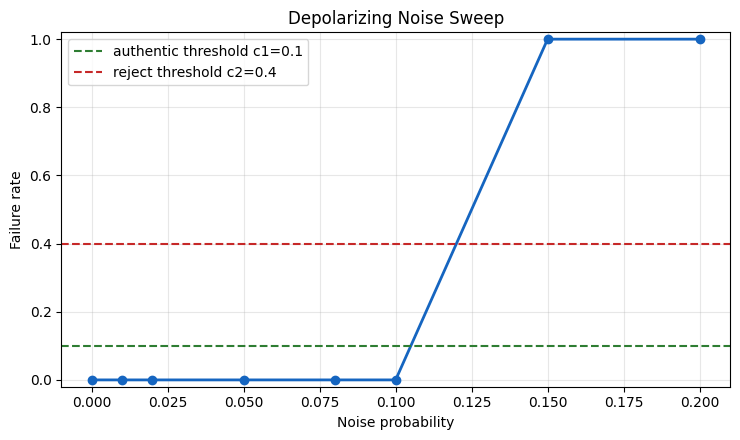

[(0.0, 0.0, 'ACCEPT_AUTHENTIC'),
 (0.01, 0.0, 'ACCEPT_AUTHENTIC'),
 (0.02, 0.0, 'ACCEPT_AUTHENTIC'),
 (0.05, 0.0, 'ACCEPT_AUTHENTIC'),
 (0.08, 0.0, 'ACCEPT_AUTHENTIC'),
 (0.1, 0.0, 'ACCEPT_AUTHENTIC'),
 (0.15, 1.0, 'REJECT_FORGED'),
 (0.2, 1.0, 'REJECT_FORGED')]

In [7]:
p_values = [0.0, 0.01, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20]

sweep_results = qds_clean.plot_noise_sweep(
    p_values=p_values,
    noise_channel="depolarizing",
)

[(item["noise_probability"], item["failure_rate"], item["verdict"]) for item in sweep_results]

## Optional SWAP Test Demonstration

The SWAP test estimates state similarity through

$$
P(\text{ancilla}=0) = \frac{1 + \operatorname{Tr}(\rho\sigma)}{2},
$$

which reduces to `(1 + |<a|b>|^2) / 2` for pure states. The demonstration compares an ideal public key with itself, with its received channel output, and with the complementary public key for the same bit position and copy.

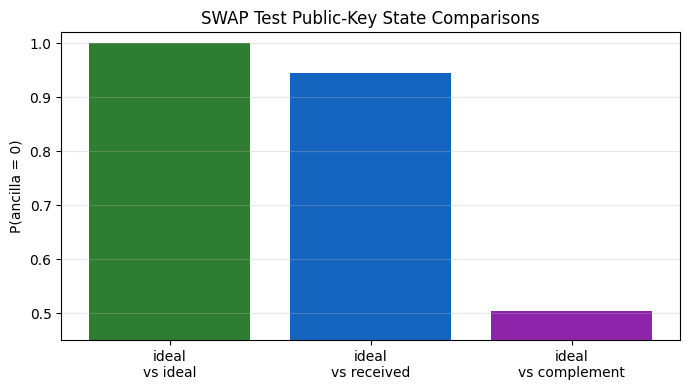

{'ideal_vs_ideal': {'p_ancilla_zero': 1.0, 'counts': {'0': 4096}},
 'ideal_vs_received': {'p_ancilla_zero': 0.945556640625,
  'counts': {'0': 3873, '1': 223}},
 'ideal_vs_complementary': {'p_ancilla_zero': 0.50390625,
  'counts': {'0': 2064, '1': 2032}}}

In [8]:
swap_result = qds_noisy.run_swap_test_example(
    bit_index=0,
    copy_index=0,
    make_plot=True,
)

{
    label: {
        "p_ancilla_zero": data["p_ancilla_zero"],
        "counts": data["counts"],
    }
    for label, data in swap_result["comparisons"].items()
}

## Final Clean Execution Cell

A compact summary from the main noisy run is printed below.

In [9]:
print("Compact QDS summary")
print("-" * 48)
print(f"Message bits         : {noisy_result['message_bits']}")
print(f"Channel              : {noisy_result['noise_channel']}")
print(f"Noise probability    : {noisy_result['noise_probability']}")
print(f"Security margin      : {noisy_result['security_margin']}")
print(f"Total checks         : {noisy_result['total_verifications']}")
print(f"Failed checks        : {noisy_result['failed_verifications']}")
print(f"Failure rate         : {noisy_result['failure_rate']:.4f}")
print(f"Verdict              : {noisy_result['verdict']}")

Compact QDS summary
------------------------------------------------
Message bits         : 101100
Channel              : depolarizing
Noise probability    : 0.05
Security margin      : 5
Total checks         : 30
Failed checks        : 0
Failure rate         : 0.0000
Verdict              : ACCEPT_AUTHENTIC
